#  Pipeline URL-Only — 52 features

**Projet** : Phishing URL Detector (M1 Informatique — ENI Fianarantsoa)
**Auteur** : REHARINA Ange Steven
**Rôle** : Machine Learning & Dataset

---

##  Objectif de ce notebook

Ce notebook documente **le pipeline final retenu pour le projet** :

- Passage de **87 features originales** à **52 features URL-only**
- Entraînement du modèle final (Random Forest)
- Évaluation et export pour la production

**Différence avec `01_phishing_detector_pipeline.ipynb`** :

| Notebook | Features | Usage |
|----------|----------|-------|
| `01` | 87 (dont 21 HTML) | Exploration initiale |
| **`02`** | **52 URL-only** | **Pipeline final** |

### Pourquoi réduire ?

1. **21 features HTML** nécessitent une requête HTTP → URLs de phishing mortes
2. **Certaines features lexicales** non reproductibles (47-53% de correspondance)
3. **Résultat** : modèle qui ne dépend QUE de la chaîne URL


In [2]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import sys
import joblib
import warnings

# Imports scikit-learn
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

# Imports du projet
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from feature_extractor import extract_features

warnings.filterwarnings('ignore')

print(f" Python     : {sys.version.split()[0]}")
print(f" pandas     : {pd.__version__}")
print(f" sklearn    : {sklearn.__version__}")
print(f" numpy      : {np.__version__}")

 Python     : 3.12.14
 pandas     : 3.0.5
 sklearn    : 1.9.0
 numpy      : 2.5.2


##  Chargement du dataset réextrait

Le fichier `data/processed/dataset_reextracted_url_only.csv` a été généré par
`tools/retrain_url_only.py`. Il contient les **52 features URL-only** réextraites
depuis les URLs brutes du dataset original.

In [3]:
DATASET_PROCESSED = '../data/processed/dataset_reextracted_url_only.csv'
FEATURE_LIST      = '../models/feature_list.json'

with open(FEATURE_LIST, 'r') as f:
    feature_list = json.load(f)

print(f" Nombre de features : {len(feature_list)}")
print(f" 10 premières       : {feature_list[:10]}")

df = pd.read_csv(DATASET_PROCESSED)
print(f"\n Dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

 Nombre de features : 52
 10 premières       : ['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_eq', 'nb_underscore']

 Dataset : 11430 lignes × 54 colonnes


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,avg_words_raw,avg_word_host,avg_word_path,phish_hints,domain_in_brand,brand_in_subdomain,brand_in_path,suspecious_tld,url,status
0,37.0,19.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.666667,7.00,4.500000,0.0,0.0,0.0,0.0,0.0,http://www.crestonwood.com/router.php,legitimate
1,77.0,23.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.750000,19.00,14.666667,0.0,0.0,0.0,0.0,0.0,http://shadetreetechnology.com/V4/validation/a...,phishing
2,126.0,50.0,0.0,4.0,1.0,0.0,1.0,2.0,3.0,2.0,...,8.727273,10.75,8.142857,3.0,0.0,1.0,0.0,0.0,https://support-appleld.com.secureupdate.duila...,phishing
3,18.0,11.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.000000,5.00,0.000000,0.0,0.0,0.0,0.0,0.0,http://rgipt.ac.in,legitimate
4,55.0,15.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,7.000000,5.00,7.000000,0.0,0.0,0.0,0.0,0.0,http://www.iracing.com/tracks/gateway-motorspo...,legitimate


##  Vérification de cohérence

In [4]:
missing_features = [f for f in feature_list if f not in df.columns]
extra_features   = [c for c in df.columns if c not in feature_list + ['url', 'status']]

print(" Vérification :")
print(f"  - Manquantes : {missing_features if missing_features else ' aucune'}")
print(f"  - En trop    : {extra_features if extra_features else ' aucune'}")
print(f"\n Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"\n Distribution :")
print(df['status'].value_counts())

 Vérification :
  - Manquantes :  aucune
  - En trop    :  aucune

 Valeurs manquantes : 0

 Distribution :
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


## Visualisation de la cible

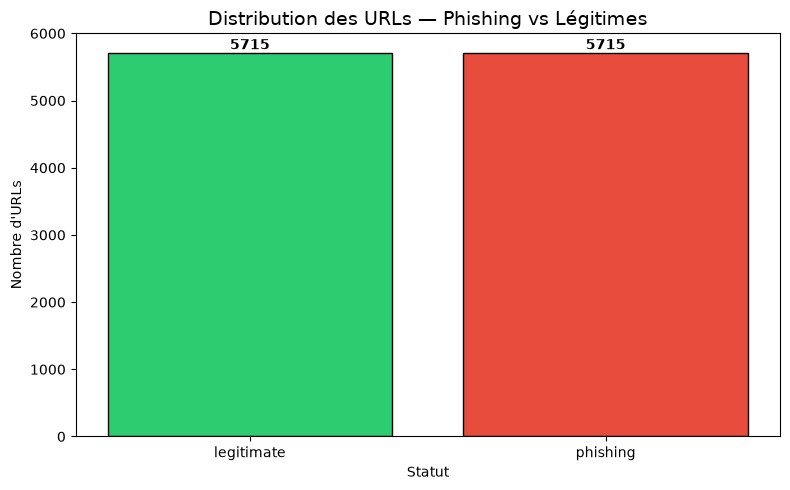

In [5]:
plt.figure(figsize=(8, 5))
counts = df['status'].value_counts()
colors = ['#2ecc71' if s == 'legitimate' else '#e74c3c' for s in counts.index]
plt.bar(counts.index, counts.values, color=colors, edgecolor='black')
plt.title('Distribution des URLs — Phishing vs Légitimes', fontsize=14)
plt.xlabel('Statut')
plt.ylabel('Nombre d\'URLs')
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Préparation X / y

In [6]:
X = df[feature_list].copy()
y = df['status'].copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f" X : {X.shape}")
print(f" y : {y_encoded.shape}")
print(f"   - {le.classes_[0]} → 0")
print(f"   - {le.classes_[1]} → 1")

 X : (11430, 52)
 y : (11430,)
   - legitimate → 0
   - phishing → 1


##  Split Train / Test (80 / 20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f" Split :")
print(f"  - Train : {X_train.shape[0]} lignes")
print(f"  - Test  : {X_test.shape[0]} lignes")

 Split :
  - Train : 9144 lignes
  - Test  : 2286 lignes


## Standardisation

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f" Train : mean={X_train_scaled.mean():.3f}, std={X_train_scaled.std():.3f}")
print(f" Test  : mean={X_test_scaled.mean():.3f}, std={X_test_scaled.std():.3f}")

 Train : mean=-0.000, std=1.000
 Test  : mean=0.009, std=0.990


## Entraînement du Random Forest

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

print("=" * 60)
print(" RÉSULTATS — RANDOM FOREST (52 features URL-only)")
print("=" * 60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC   : {roc_auc_score(y_test, y_pred):.4f}")

print("\n Classification Report :")
print(classification_report(y_test, y_pred, target_names=le.classes_))

 RÉSULTATS — RANDOM FOREST (52 features URL-only)
Accuracy  : 0.9020
Precision : 0.9013
Recall    : 0.9029
F1-Score  : 0.9021
AUC-ROC   : 0.9020

 Classification Report :
              precision    recall  f1-score   support

  legitimate       0.90      0.90      0.90      1143
    phishing       0.90      0.90      0.90      1143

    accuracy                           0.90      2286
   macro avg       0.90      0.90      0.90      2286
weighted avg       0.90      0.90      0.90      2286



## Matrice de confusion

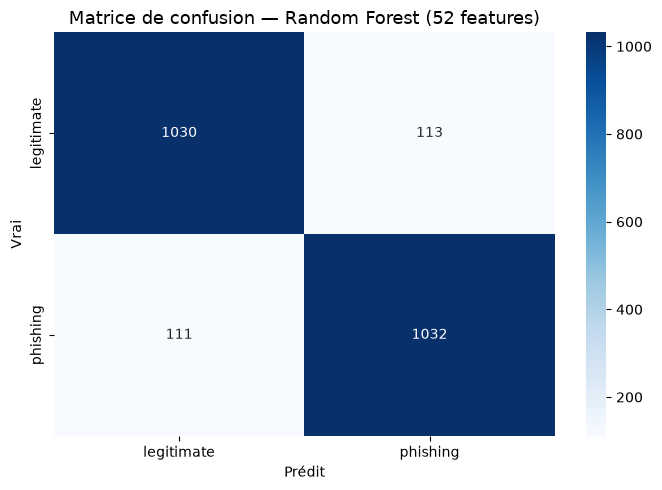

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de confusion — Random Forest (52 features)', fontsize=13)
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

## Importance des features

 TOP 20 :
           feature  importance
            nb_www    0.082898
  length_words_raw    0.066486
 longest_word_path    0.061258
shortest_word_host    0.056429
       char_repeat    0.056212
  ratio_digits_url    0.052167
 longest_words_raw    0.047992
       phish_hints    0.047023
        nb_hyphens    0.045810
        length_url    0.044714
          nb_slash    0.041429
   length_hostname    0.041292
     avg_word_host    0.033427
     avg_word_path    0.032955
 ratio_digits_host    0.032128
           nb_dots    0.031628
shortest_words_raw    0.030201
     nb_subdomains    0.029767
 longest_word_host    0.028908
     avg_words_raw    0.028101


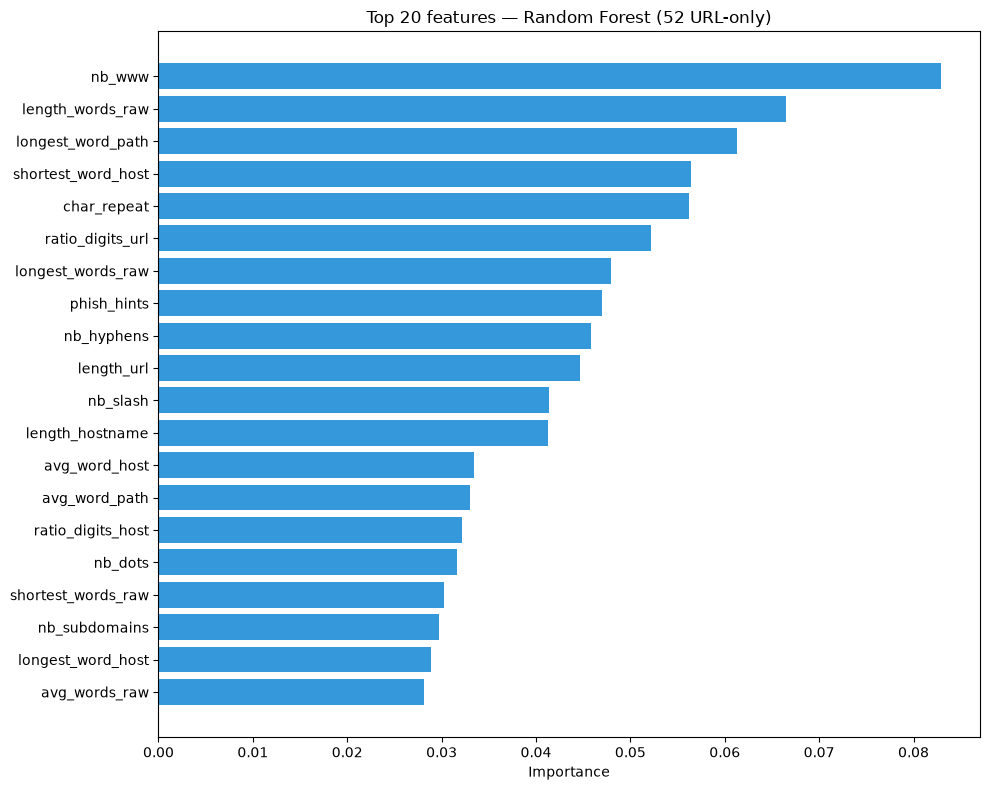

In [11]:
importance = pd.DataFrame({
    'feature'    : feature_list,
    'importance' : rf.feature_importances_
}).sort_values('importance', ascending=False)

print(" TOP 20 :")
print(importance.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
top20 = importance.head(20)
plt.barh(top20['feature'], top20['importance'], color='#3498db')
plt.xlabel('Importance')
plt.title('Top 20 features — Random Forest (52 URL-only)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##  Validation croisée (5-fold)

In [12]:
cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='f1')

print(f" Validation croisée (F1) :")
print(f"  - Scores  : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  - Moyenne : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

 Validation croisée (F1) :
  - Scores  : ['0.8798', '0.8921', '0.8852', '0.9019', '0.9044']
  - Moyenne : 0.8927 (+/- 0.0094)


##  Comparaison 87 features vs 52 features

Rappel : le passage de 87 à 52 features **sacrifie un peu d'accuracy**
au profit de la reproductibilité et de l'indépendance au réseau.

In [13]:
comparison = pd.DataFrame({
    'Pipeline'   : ['87 features (initial)', '52 features URL-only (final)'],
    'Features'   : [87, 52],
    'Accuracy'   : [0.9506, accuracy_score(y_test, y_pred)],
    'F1-Score'   : [0.9507, f1_score(y_test, y_pred)],
    'Production' : [' HTML requis', ' URL seule']
})

print(" COMPARAISON DES PIPELINES :")
print(comparison.to_string(index=False))

 COMPARAISON DES PIPELINES :
                    Pipeline  Features  Accuracy  F1-Score   Production
       87 features (initial)        87  0.950600  0.950700  HTML requis
52 features URL-only (final)        52  0.902012  0.902098    URL seule


##  Test de prédiction en direct

In [14]:
def predict_url(url, model=rf, scaler=scaler, encoder=le, features=feature_list):
    feats = extract_features(url, feature_order=features)
    x = np.array([feats])
    x_scaled = scaler.transform(x)
    pred = model.predict(x_scaled)[0]
    proba = model.predict_proba(x_scaled)[0]
    return {
        'url'         : url,
        'prediction'  : encoder.inverse_transform([pred])[0],
        'confidence'  : float(max(proba)),
        'proba_phish' : float(proba[encoder.transform(['phishing'])[0]]),
    }

test_urls = [
    "https://www.google.com",
    "https://github.com/features/copilot",
    "http://paypal-secure-login.xyz/verify?id=12345",
    "http://192.168.1.1/login.php",
    "https://www.wikipedia.org/wiki/Phishing",
]

print(" TESTS DE PRÉDICTION EN DIRECT :\n")
for url in test_urls:
    try:
        r = predict_url(url)
        icon = "🔴" if r['prediction'] == 'phishing' else "🟢"
        print(f"{icon} {r['prediction'].upper():10s} (confiance {r['confidence']:.1%}) — {url}")
    except Exception as e:
        print(f" ERREUR pour {url} : {e}")

 TESTS DE PRÉDICTION EN DIRECT :

🟢 LEGITIMATE (confiance 94.3%) — https://www.google.com
🟢 LEGITIMATE (confiance 54.8%) — https://github.com/features/copilot
🔴 PHISHING   (confiance 90.3%) — http://paypal-secure-login.xyz/verify?id=12345
🔴 PHISHING   (confiance 96.3%) — http://192.168.1.1/login.php
🟢 LEGITIMATE (confiance 91.2%) — https://www.wikipedia.org/wiki/Phishing


## Sauvegarde du modèle final

In [15]:
os.makedirs('../models', exist_ok=True)

joblib.dump(rf,     '../models/best_model.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
joblib.dump(le,     '../models/label_encoder.joblib')

with open('../models/feature_list.json', 'w') as f:
    json.dump(feature_list, f, indent=2)

print(" Modèle sauvegardé dans models/")
for f in ['best_model.joblib', 'scaler.joblib', 'label_encoder.joblib', 'feature_list.json']:
    size = os.path.getsize(f'../models/{f}') / 1024
    print(f"   - {f} ({size:.1f} KB)")

 Modèle sauvegardé dans models/
   - best_model.joblib (20687.7 KB)
   - scaler.joblib (2.8 KB)
   - label_encoder.joblib (0.5 KB)
   - feature_list.json (0.9 KB)


## Conclusion

### Résultats finaux

| Étape | Résultat |
|-------|----------|
| Features | 52 URL-only |
| Modèle | Random Forest (200 arbres, max_depth=20) |
| Accuracy | 90.2% |
| F1-Score | 90.2% |
| Validation croisée (F1) | 89.3% ± 0.9% |
| Inférence | < 1 ms, 100% locale |

### Justification du compromis

- **Reproductible** : aucune dépendance au site cible
- **Robuste** : fonctionne même sur URLs mortes (phishing de 2020)
- **Cohérent** : train et serve utilisent le même extracteur
- **Léger** : modèle de 20 MB, inférence < 1 ms

**Compromis assumé** : on perd ~5 points d'accuracy (95% → 90%) par rapport
au pipeline HTML, mais on gagne la **reproductibilité en production**.

### Pipeline final

### Suite du projet

- `src/predict.py` : prêt
- `api/main.py` : à venir (Membre 3)
- `app/app.py` : à venir (Membre 4)
- `tests/` : à venir (Membre 5)
- Déploiement Hugging Face : à venir (Membre 6)
